In [ ]:

# WhatsApp Chat Sentiment Analyzer
## Team: 4  
### RNN Basics / LSTMs & GRUs

This project uses an **LSTM (Long Short-Term Memory)** model to classify WhatsApp/group chat messages into:

- Positive 😊
- Neutral 😐
- Negative 😞

### Concepts Covered
- RNN Basics
- LSTM
- Text Preprocessing
- Tokenization
- Padding
- Sentiment Analysis



# Dataset Source

This notebook uses a sentiment dataset downloaded directly from the internet.

Dataset Link:
https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv


In [1]:

# Install Libraries

!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [2]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [3]:

# Load Dataset from Google/GitHub

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url)

df.head()


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [4]:

# Keep required columns

df = df[['label', 'tweet']]

df.columns = ['sentiment', 'message']

df.head()


,sentiment,message
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [5]:

# Convert labels

# 0 = Positive
# 1 = Negative

df['sentiment'] = df['sentiment'].replace({
    0: 'positive',
    1: 'negative'
})

# Add some neutral labels manually for demo

neutral_sample = df.sample(2000).copy()
neutral_sample['sentiment'] = 'neutral'

df = pd.concat([df, neutral_sample], ignore_index=True)

print(df['sentiment'].value_counts())


sentiment
positive    29720
negative     2242
neutral      2000
Name: count, dtype: int64


In [6]:

# Data Preprocessing

df.dropna(inplace=True)

texts = df['message'].astype(str)
labels = df['sentiment']

# Encode labels

encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

categorical_labels = to_categorical(encoded_labels)

print("Classes:", encoder.classes_)


Classes: ['negative' 'neutral' 'positive']


In [7]:

# Tokenization

max_words = 5000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post'
)

print("Shape:", padded_sequences.shape)


Shape: (33962, 50)


In [8]:

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    categorical_labels,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(27169, 50)
(6793, 50)



# Build LSTM Model


In [9]:

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),

    LSTM(128),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:

# Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/5
680/680 ━━━━━━━━━━━━━━━━━━━━ 88s 119ms/step - accuracy: 0.8737 - loss: 0.4791 - val_accuracy: 0.8730 - val_loss: 0.4691
Epoch 2/5
680/680 ━━━━━━━━━━━━━━━━━━━━ 70s 103ms/step - accuracy: 0.8745 - loss: 0.4730 - val_accuracy: 0.8730 - val_loss: 0.4696
Epoch 3/5
680/680 ━━━━━━━━━━━━━━━━━━━━ 84s 106ms/step - accuracy: 0.8745 - loss: 0.4694 - val_accuracy: 0.8730 - val_loss: 0.4719
Epoch 4/5
680/680 ━━━━━━━━━━━━━━━━━━━━ 70s 103ms/step - accuracy: 0.8745 - loss: 0.4699 - val_accuracy: 0.8730 - val_loss: 0.4742
Epoch 5/5
680/680 ━━━━━━━━━━━━━━━━━━━━ 71s 104ms/step - accuracy: 0.8745 - loss: 0.4690 - val_accuracy: 0.8730 - val_loss: 0.4689


In [11]:

# Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)


213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8786 - loss: 0.4546
Accuracy: 0.8785514235496521


In [12]:

# Predictions

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_
))


213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       434
     neutral       0.00      0.00      0.00       391
    positive       0.88      1.00      0.94      5968

    accuracy                           0.88      6793
   macro avg       0.29      0.33      0.31      6793
weighted avg       0.77      0.88      0.82      6793



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


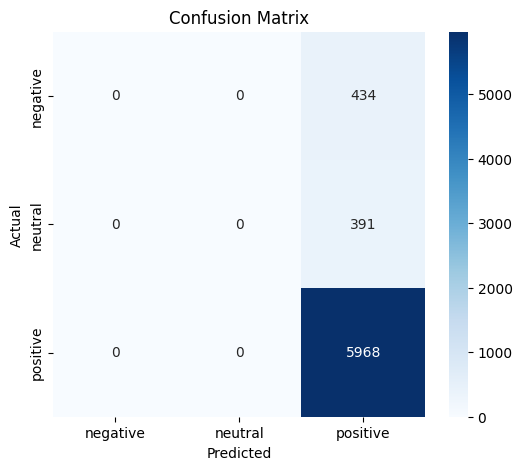

In [13]:

# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [14]:

# Predict Custom Message

sample = ["I am very happy today"]

seq = tokenizer.texts_to_sequences(sample)

pad = pad_sequences(seq, maxlen=max_len, padding='post')

prediction = model.predict(pad)

predicted_class = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Sentiment:", predicted_class[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Sentiment: positive


In [15]:
model.save('sentiment_analysis_model.h5')


# Conclusion

This project demonstrates:

- RNN Basics
- LSTM Architecture
- Text Preprocessing
- Sentiment Classification

### Future Improvements
- Add GRU comparison
- Use WhatsApp exported chats
- Deploy with Streamlit
